Control Equation of current controller and feedforward loop is:

(ids-id)(Kp+Ki/s)*(1/Ls)=d (1)

No considering disturbance the inverter voltage can be expressed as differncial function of inductor current lik as follow:

Va=L(di/dt)
dVa=(L/Ts)*(ids-id)=alpha*Kd(ids-id) (2)

alpha*Kp=L/Ts result Kp=L/(alpha*Ts)
Replacing Kp in (1) and simplify get transfer function
id/ids = (L+alpha*Ki*Ts)/(alpha*Ts*L*s^2+L*s+alpha*Ki*Ts)

In [10]:
from math import pi, sqrt
import control as ct

In [47]:
L=1.65E-3
R=0.01
Fs=1E4
Ts=1/Fs
alpha=1

In [48]:
Kp=L/(alpha*Ts)
print('Kp=',Kp)

Kp= 16.5


In [49]:
print('Ki <',L/(4*Ts*Ts*alpha*alpha))

Ki < 41250.0


In [51]:
Ki=38000
a=alpha*L*Ts
b=L
c=alpha*Ki*Ts

d = b*b - 4*a*c
print('d=',d)

z1 = (-b + sqrt(d))/(2*a)
z2 = (-b - sqrt(d))/(2*a)
print('z1=',z1)
print('z2=',z2)

d= 2.1449999999999939e-07
z1= -3596.541069465528
z2= -6403.458930534472


In [52]:
num=[L,alpha*Ki*Ts]
den=[alpha*Ts*L,L,alpha*Ki*Ts]
G=ct.tf(num,den)
print(G)

<TransferFunction>: sys[21]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         0.00165 s + 3.8
  ------------------------------
  1.65e-07 s^2 + 0.00165 s + 3.8


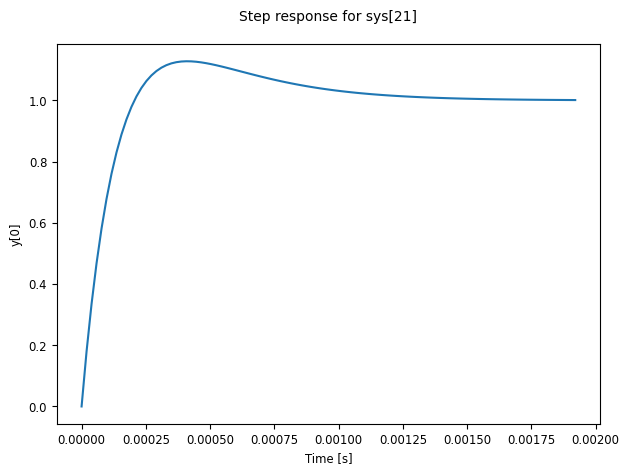

In [53]:
response = ct.step_response(G)
cplt = response.plot()

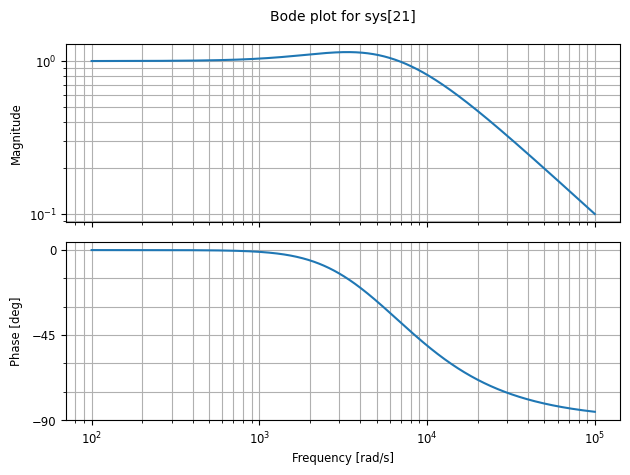

In [54]:
freqresp = ct.frequency_response(G)
cplt = freqresp.plot()